# Notebook 01 — Exploration des données AI4I 2020

## Objectif

Auditer le jeu de données industriel **AI4I 2020 Predictive Maintenance Dataset** (UCI, licence CC BY 4.0) qui servira de base au PoC MECHA. Le jeu a été préalablement enrichi de défauts réalistes (valeurs manquantes, doublons, outliers, incohérences d'encodage, valeurs sentinelles) afin de simuler une remontée SCADA/MES authentique d'une ligne de production industrielle.

À l'issue de ce notebook, nous aurons répondu à :

1. Quelle est la structure du dataset (volumes, colonnes, types) ?
2. Quelle est sa qualité brute (manquants, doublons, outliers, incohérences) ?
3. Quelle est la distribution de chaque variable par typologie ?
4. Quelles variables sont liées aux défaillances machine ?
5. Comment ces données se projettent-elles dans le contexte métier MECHA ?

## Rattachement à la grille MSPR (Bloc 3)

| Compétence | Critère | Section |
|---|---|---|
| C1 — Collecter les besoins | Liste des sources, vocabulaire technique | §1 |
| C5 — Data visualisation | Histogrammes, boxplots, heatmap, countplots | §4 à §8, §11 |
| C8 — Qualité des données | Mesure quantifiée des défauts | §2, §3, §9, §12 |

## Source

Matzka, S. (2020). *AI4I 2020 Predictive Maintenance Dataset*. UCI Machine Learning Repository (id 601). Licence CC BY 4.0.

Le dataset a été enrichi de défauts suivant la méthodologie documentée dans `docs/injection_defauts.md` pour se rapprocher d'une réalité industrielle MECHA.


## 1. Chargement et structure

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/raw/ai4i2020.csv")
print(df.shape)
df.head(3)

(10070, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1122,L48301,L,296.6,307.6,1459.0,40.2,96,0,0,0,0,0,0
1,319,L47498,L,297.8,308.4,1512.0,39.9,181,0,0,0,0,0,0
2,9134,L56313,L,297.7,308.7,1479.0,45.7,93,0,0,0,0,0,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10070 entries, 0 to 10069
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10070 non-null  int64  
 1   Product ID               10070 non-null  str    
 2   Type                     10070 non-null  str    
 3   Air temperature [K]      9819 non-null   float64
 4   Process temperature [K]  9822 non-null   float64
 5   Rotational speed [rpm]   9819 non-null   float64
 6   Torque [Nm]              9797 non-null   str    
 7   Tool wear [min]          9799 non-null   str    
 8   Machine failure          10070 non-null  int64  
 9   TWF                      10070 non-null  int64  
 10  HDF                      10070 non-null  int64  
 11  PWF                      10070 non-null  int64  
 12  OSF                      10070 non-null  int64  
 13  RNF                      10070 non-null  int64  
dtypes: float64(3), int64(7), str(4)
m

In [56]:
df.dtypes.value_counts()

int64      7
str        4
float64    3
Name: count, dtype: int64

## 2. Audit qualité brute

Trois indicateurs clés avant toute analyse : valeurs manquantes, doublons, types incohérents.


                         valeurs manquantes %
Torque [Nm]                              2.71
Tool wear [min]                          2.69
Rotational speed [rpm]                   2.49
Air temperature [K]                      2.49
Process temperature [K]                  2.46


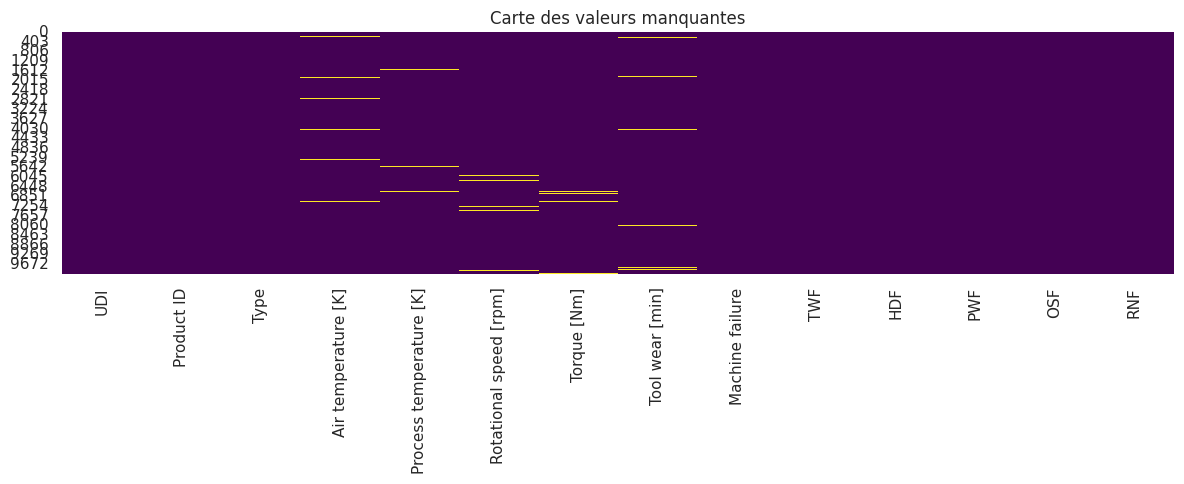

In [57]:
missing = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0].to_frame(name="valeurs manquantes %").round(2)
print(missing)

plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), annot=False, cmap="viridis", cbar=False)
plt.title("Carte des valeurs manquantes")
plt.tight_layout()
plt.show()

In [58]:
print(f"Doublons lignes identiques : {df.duplicated().sum()}")
print(f"Doublons UDI              : {df['UDI'].duplicated().sum()}")
print(f"Doublons Product ID       : {df['Product ID'].duplicated().sum()}")

Doublons lignes identiques : 65
Doublons UDI              : 70
Doublons Product ID       : 70


## 3. Typologie des variables

On classe les 14 colonnes selon leur nature pour adapter les traitements (univarié, bivarié, choix des tests statistiques du notebook 01bis, choix du préprocessing du notebook 07).


In [59]:
variables_continues  = ["Air temperature [K]", "Process temperature [K]", "Torque [Nm]"]
variables_discretes  = ["Rotational speed [rpm]", "Tool wear [min]"]
variables_categoriel = ["Type"]
variables_binaire    = ["TWF", "HDF", "PWF", "OSF", "RNF"]
variables_cible      = ["Machine failure"]

print(f"Continues   : {variables_continues}")
print(f"Discretes   : {variables_discretes}")
print(f"Categoriel  : {variables_categoriel}")
print(f"Binaires    : {variables_binaire}")
print(f"Cible       : {variables_cible}")

Continues   : ['Air temperature [K]', 'Process temperature [K]', 'Torque [Nm]']
Discretes   : ['Rotational speed [rpm]', 'Tool wear [min]']
Categoriel  : ['Type']
Binaires    : ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Cible       : ['Machine failure']


Les colonnes `Torque` et `Tool wear` contiennent du texte injecté (`"N/A"`, `"null"`, `"-"`, `"NaN"`, `"#ERROR"`) pour simuler un mauvais parsing SCADA. On crée un DataFrame `df_num` avec cast numérique pour pouvoir visualiser. Le nettoyage définitif sera réalisé dans le notebook 03.


In [60]:
cols_numeriques = variables_continues + variables_discretes + variables_binaire + variables_cible
df_num = df[cols_numeriques].apply(pd.to_numeric, errors="coerce")
print(df_num.dtypes)
print(f"\nMissing apres cast : {df_num.isna().sum().sum()}")

Air temperature [K]        float64
Process temperature [K]    float64
Torque [Nm]                float64
Rotational speed [rpm]     float64
Tool wear [min]            float64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Machine failure              int64
dtype: object

Missing apres cast : 1309


## 4. Analyse des variables continues

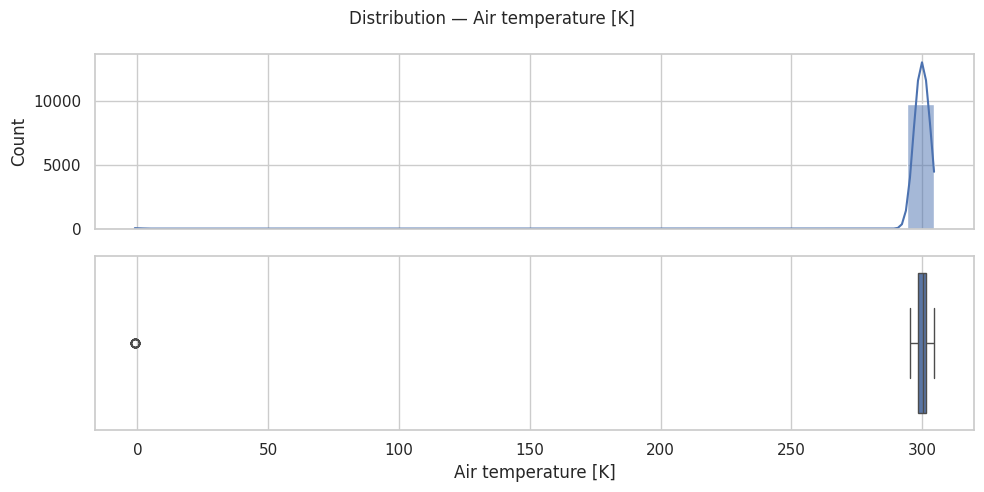

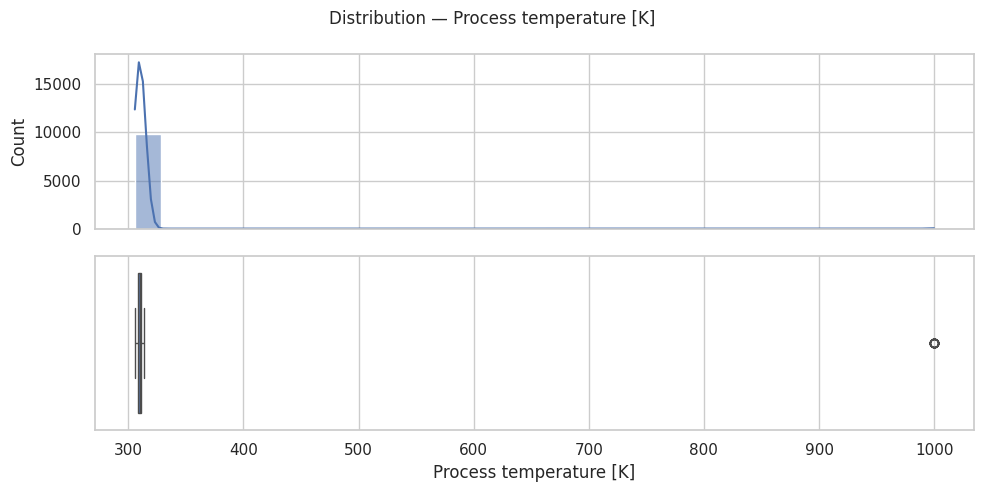

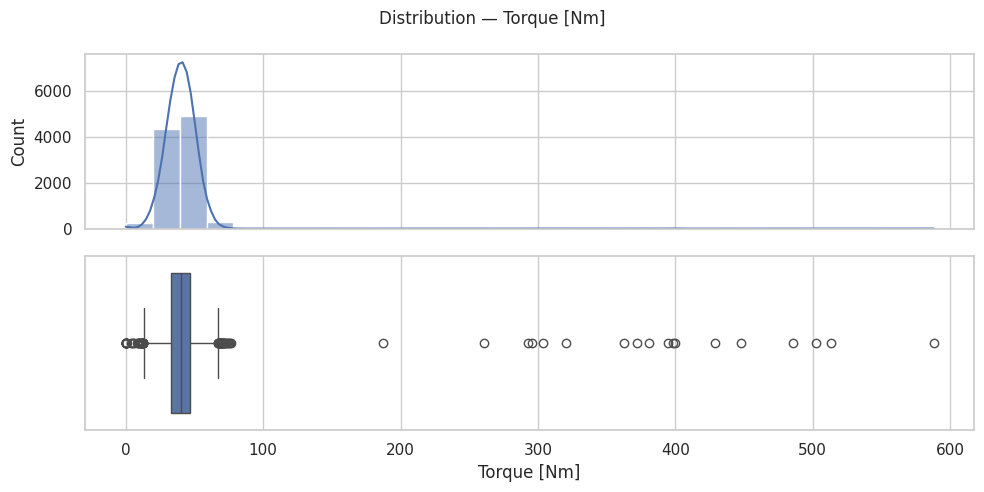

In [61]:
for col in variables_continues:
    fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    plt.suptitle(f"Distribution — {col}", fontsize=12)
    sns.histplot(df_num[col].dropna(), bins=30, kde=True, ax=ax[0])
    sns.boxplot(x=df_num[col].dropna(), ax=ax[1])
    plt.tight_layout()
    plt.show()

## 5. Analyse des variables discrètes

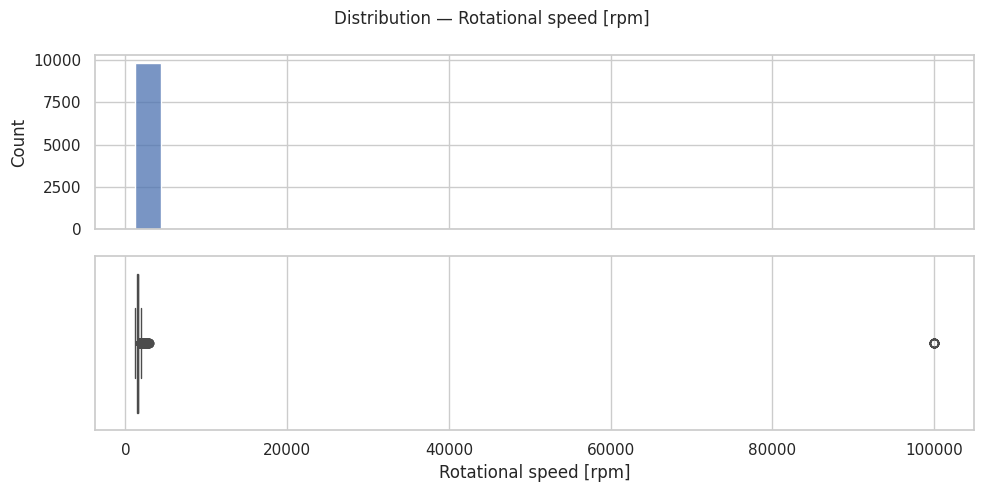

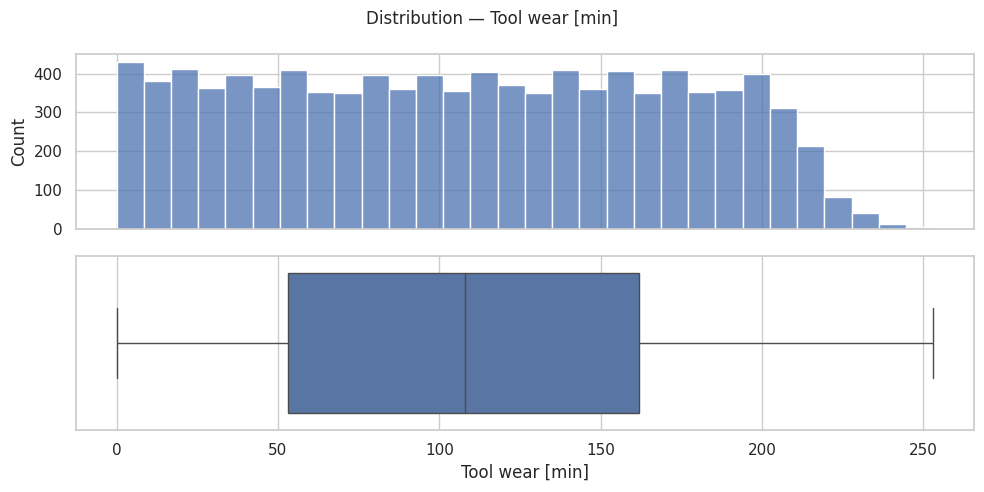

In [62]:
for col in variables_discretes:
    fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
    plt.suptitle(f"Distribution — {col}", fontsize=12)
    sns.histplot(df_num[col].dropna(), bins=30, kde=False, ax=ax[0])
    sns.boxplot(x=df_num[col].dropna(), ax=ax[1])
    plt.tight_layout()
    plt.show()

## 6. Analyse des variables catégorielles

La colonne `Type` devrait contenir uniquement 3 valeurs (L, M, H). L'injection d'incohérences d'encodage (casse, espaces) nous permet de visualiser une pollution typique des saisies manuelles côté MES.


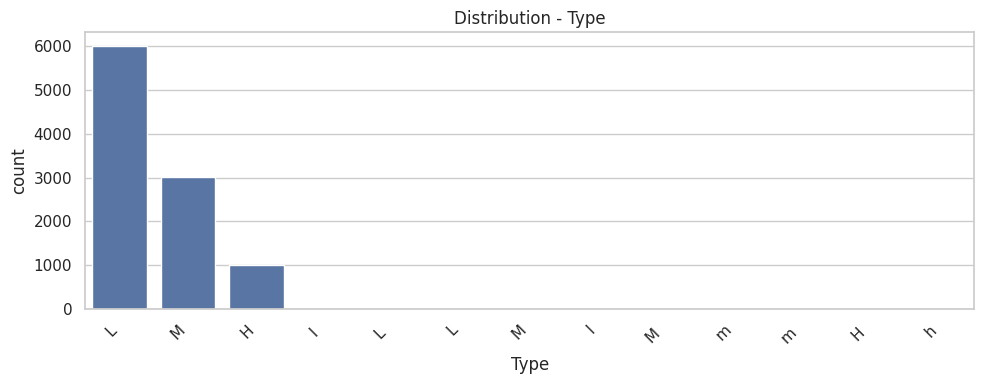

Type
L      6006
M      3006
H      1008
 l       13
L         9
 L        7
 M        6
l         6
M         3
m         2
 m        2
H         1
h         1
Name: count, dtype: int64


In [63]:
for col in variables_categoriel:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution - {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print(df["Type"].value_counts())

## 7. Analyse des variables binaires (sous-types de défaillance)

Les 5 sous-types de défaillance :
- **TWF** (Tool Wear Failure) — usure outil
- **HDF** (Heat Dissipation Failure) — chaleur
- **PWF** (Power Failure) — puissance
- **OSF** (Overstrain Failure) — surcharge
- **RNF** (Random Failure) — aléatoire


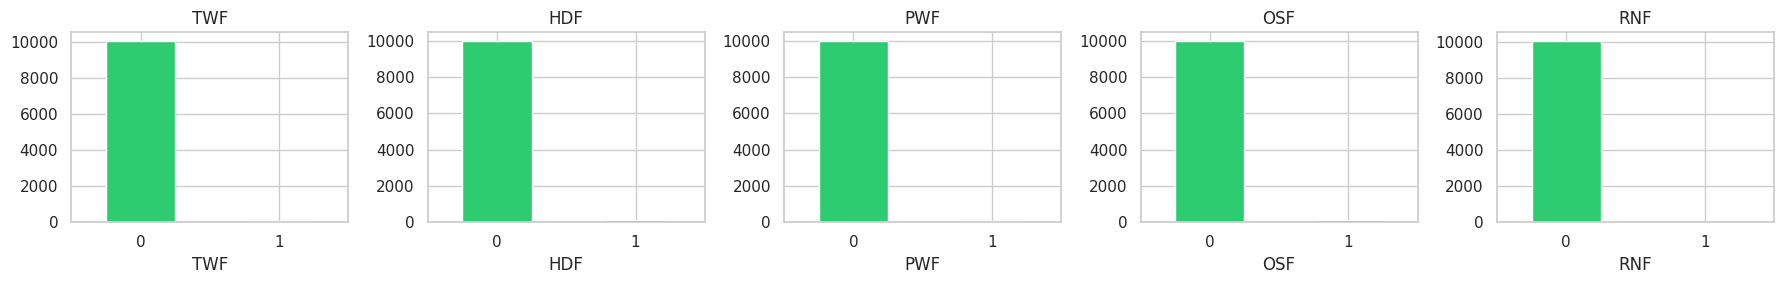

HDF    116
OSF     98
PWF     95
TWF     47
RNF     19
dtype: int64


In [64]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for i, col in enumerate(variables_binaire):
    df_num[col].value_counts().plot(kind="bar", ax=axes[i], title=col, color=["#2ecc71", "#e74c3c"])
    axes[i].set_xticklabels([0, 1], rotation=0)
plt.tight_layout()
plt.show()

print(df_num[variables_binaire].sum().sort_values(ascending=False))

## 8. Analyse de la variable cible (Machine failure)

Dans un contexte industriel, la panne est rare par nature (objectif qualité = faible taux de rebut). Le déséquilibre de classe conditionne tout le travail ML à venir dans le notebook 07 (choix des métriques PR-AUC plutôt que ROC-AUC, rééquilibrage SMOTE, ajustement des seuils de décision).


                 count    pct
Machine failure              
0                 9714  96.46
1                  356   3.54


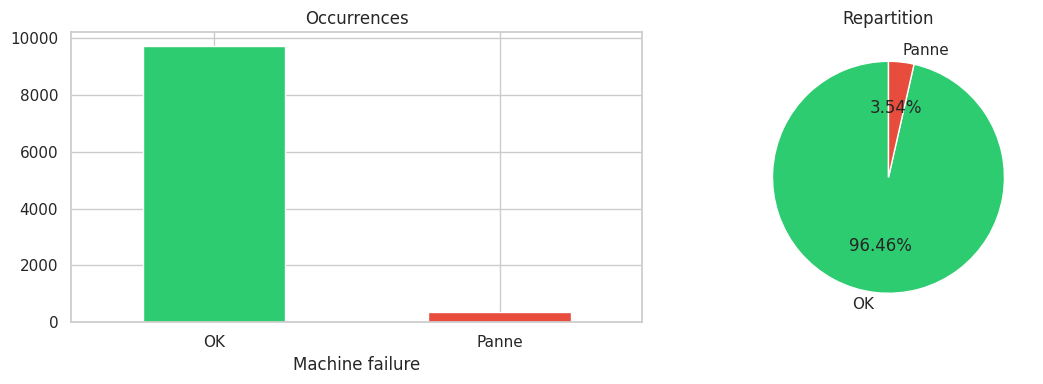

In [65]:
counts = df_num["Machine failure"].value_counts()
pct = df_num["Machine failure"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "pct": pct.round(2)}))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind="bar", ax=ax[0], color=["#2ecc71", "#e74c3c"])
ax[0].set_title("Occurrences")
ax[0].set_xticklabels(["OK", "Panne"], rotation=0)

ax[1].pie(counts, labels=["OK", "Panne"], autopct="%1.2f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
ax[1].set_title("Repartition")
plt.tight_layout()
plt.show()

## 9. Rapport outliers (méthode IQR)

Règle classique : une valeur est considérée comme outlier si elle sort de `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. C'est la méthode retenue pour le nettoyage dans le notebook 03.


In [66]:
outliers_report = []
for col in cols_numeriques:
    q1 = df_num[col].quantile(0.25)
    q3 = df_num[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_out = ((df_num[col] < low) | (df_num[col] > high)).sum()
    outliers_report.append({
        "colonne": col,
        "outliers": int(n_out),
        "pct": round(n_out / len(df_num) * 100, 2)
    })

pd.DataFrame(outliers_report).sort_values("outliers", ascending=False)

,colonne,outliers,pct
3,Rotational speed [rpm],426,4.23
10,Machine failure,356,3.54
6,HDF,116,1.15
2,Torque [Nm],111,1.10
8,OSF,98,0.97
7,PWF,95,0.94
5,TWF,47,0.47
1,Process temperature [K],20,0.20
0,Air temperature [K],20,0.20
9,RNF,19,0.19


## 10. Corrélations entre capteurs et défaillances

Première indication visuelle des variables potentiellement utiles pour le ML. La validation statistique (significativité, p-values) sera réalisée dans le notebook 01bis.


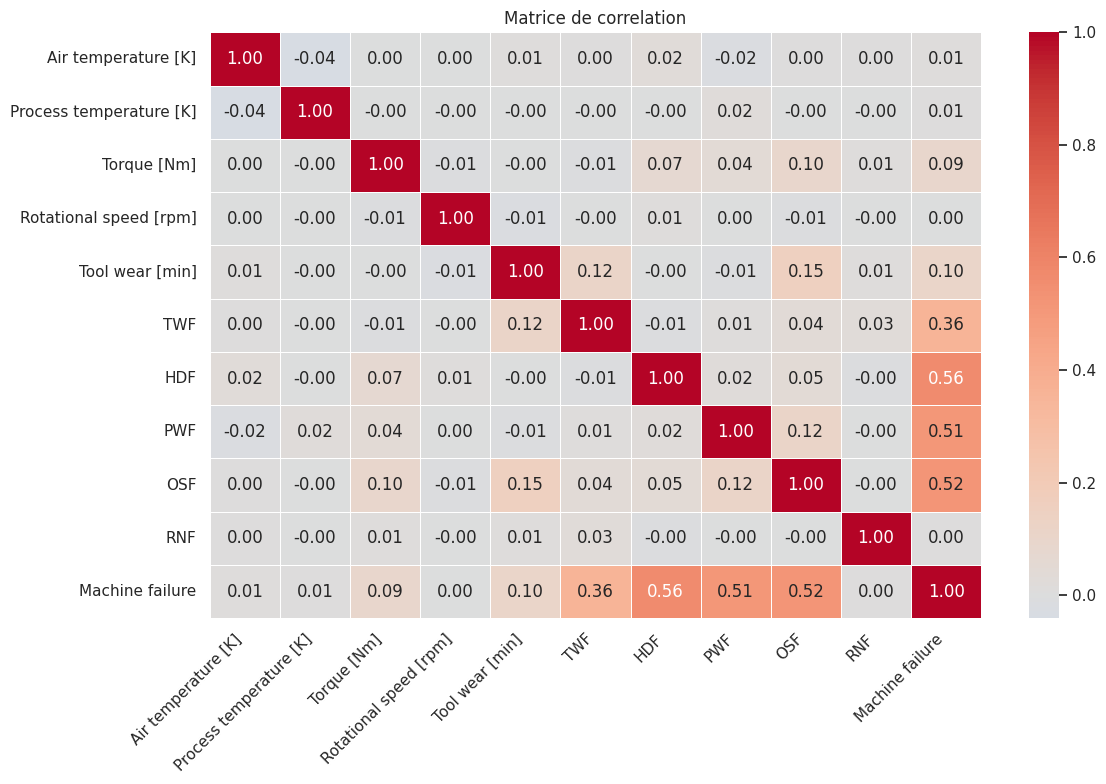

In [67]:
corr = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matrice de correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [68]:
print("Top correlations avec Machine failure :")
print(corr["Machine failure"].drop("Machine failure").sort_values(key=abs, ascending=False).round(3))

Top correlations avec Machine failure :
HDF                        0.564
OSF                        0.518
PWF                        0.510
TWF                        0.358
Tool wear [min]            0.102
Torque [Nm]                0.093
Air temperature [K]        0.008
Process temperature [K]    0.006
RNF                        0.004
Rotational speed [rpm]     0.002
Name: Machine failure, dtype: float64


## 11. Comparaison capteurs : pièces OK vs pièces en panne

/tmp/ipykernel_13754/4188796429.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_13754/4188796429.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_13754/4188796429.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_13754/4188796429.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["OK", "Panne"])
/tmp/ipykernel_13754/4188796429.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator

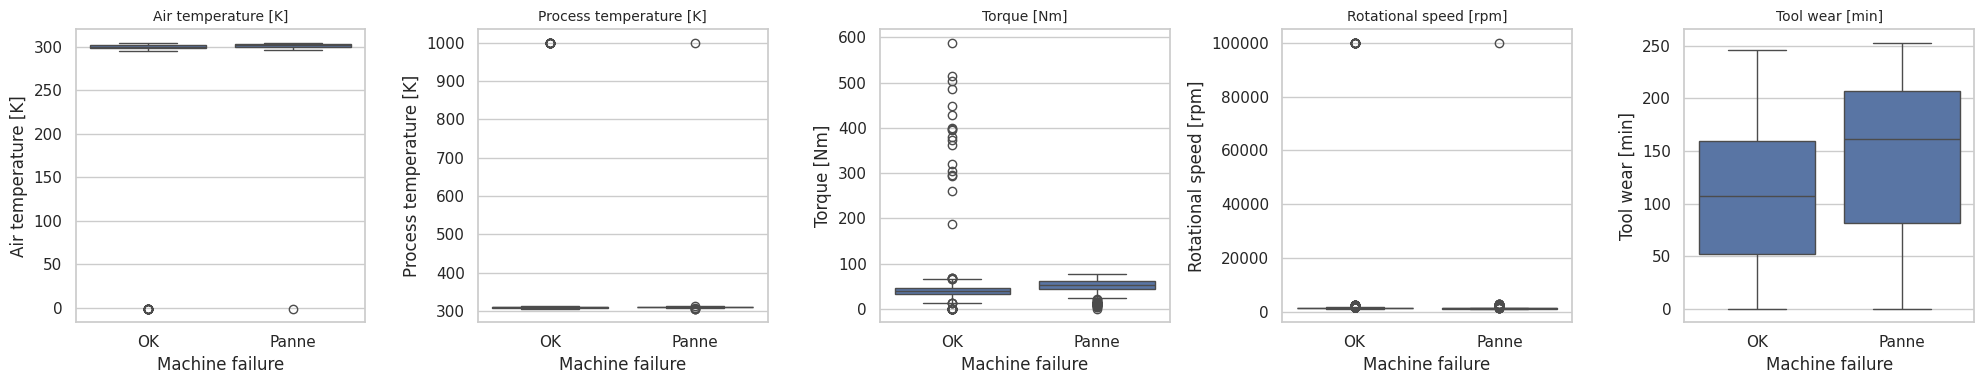

In [69]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(variables_continues + variables_discretes):
    sns.boxplot(data=df_num, x="Machine failure", y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticklabels(["OK", "Panne"])
plt.tight_layout()
plt.show()

## 12. Synthèse de l'audit

### Qualité des données (avant nettoyage)

| Type de défaut | Volume observé | Cause industrielle probable |
|---|---|---|
| Valeurs manquantes | ~250 par capteur (2.5%) | Capteur en panne, perte réseau |
| Doublons lignes | 65 | Retransmission SCADA |
| Doublons UDI | 70 | Même pièce remontée plusieurs fois |
| Texte dans numérique | ~60 | Mauvais parsing JSON/XML SCADA |
| Outliers extrêmes | ~100 | Pics électriques, capteurs HS |
| Valeurs sentinelles | -1, 999.9, 99999 | Capteurs qui renvoient des codes d'erreur |
| Encodage incohérent | 13 variantes de `Type` | Saisie manuelle MES |
| Labels contradictoires | 15 | Erreur saisie opérateur |

### Enseignements métier

- **Classe très déséquilibrée** (~3.4% de pannes) → ML devra utiliser SMOTE ou `class_weight`
- **Type L** représente ~60% du volume → pièces grand public, moins de marge qualité
- **Tool wear** et **Torque** semblent les capteurs les plus liés aux pannes → candidats prioritaires pour les features du modèle
- Les 5 sous-types permettront une **analyse causale** fine des défauts

### Projection MECHA

| Variable AI4I | Équivalent MECHA |
|---|---|
| UDI, Product ID | Identifiant pièce (traçabilité aéronautique/automobile) |
| Type (L/M/H) | Gamme produit (auto vs aéronautique vs haute précision) |
| Air / Process temperature | Capteurs IoT ateliers |
| Rotational speed, Torque | Paramètres fraiseuse CNC |
| Tool wear | Usure cumulée de l'outil de coupe |
| Machine failure + 5 sous-types | Rebut + typologie des défauts |

### Suite du parcours

- **Notebook 01bis** — Tests d'hypothèses statistiques (Khi², t-test, Mann-Whitney, ANOVA) pour valider les observations
- **Notebook 02** — Ingestion bronze : split 2 usines (FR-01, ES-01) + horodatage
- **Notebook 03** — Qualité des données : détection Pandera + nettoyage + rapport avant/après
- **Notebook 04** — Calcul des KPIs métiers (TRS, rebut, disponibilité, cycle time)
- **Notebook 05** — Entrepôt multidimensionnel en étoile (DuckDB)
- **Notebook 06** — Feature engineering (création de variables dérivées)
- **Notebook 07** — Machine Learning + MLflow (XGBoost, Random Forest, Logistic Regression)
- **Notebook 08** — Système d'alertes priorisé (règles métiers + priorités critique/majeur/mineur)
